# Project 1 — Lasso Regression
## Startup Valuation Prediction (with irrelevant features)

Predicting startup valuation from a mix of genuinely predictive features (funding raised, team size, monthly revenue, growth rate) and irrelevant noise features (founder_age, office_plants_count, logo_color_score) — a good showcase for Lasso's feature selection.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 700
funding_raised = np.random.gamma(3, 500000, n)
team_size = np.random.poisson(25, n)
monthly_revenue = np.random.gamma(2, 20000, n)
growth_rate = np.random.uniform(-0.1, 0.6, n)

# irrelevant/noise features
founder_age = np.random.randint(22, 60, n)
office_plants_count = np.random.poisson(5, n)
logo_color_score = np.random.uniform(0, 10, n)

valuation = (500000 + 3.5*funding_raised + 20000*team_size + 8*monthly_revenue
             + 2000000*growth_rate + np.random.normal(0, 400000, n))

df = pd.DataFrame({'funding_raised': funding_raised, 'team_size': team_size,
                    'monthly_revenue': monthly_revenue, 'growth_rate': growth_rate,
                    'founder_age': founder_age, 'office_plants_count': office_plants_count,
                    'logo_color_score': logo_color_score, 'valuation': valuation})
df.head()


,funding_raised,team_size,monthly_revenue,growth_rate,founder_age,office_plants_count,logo_color_score,valuation
0,1.781409e+06,21,19994.166706,0.079944,52,3,0.072199,7.571976e+06
1,1.223597e+06,26,39091.671910,0.225525,50,5,3.165963,6.488025e+06
2,1.151140e+06,28,4565.670192,0.058885,30,3,6.771907,5.381707e+06
3,1.151152e+06,24,52031.051788,0.420734,36,5,4.840389,6.703269e+06
4,3.083070e+06,18,19671.876958,0.543446,51,4,9.782695,1.287176e+07


## 2. Preprocessing

In [3]:
X = df.drop('valuation', axis=1)
y = df['valuation']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Train Model

In [4]:
from sklearn.linear_model import Lasso, LassoCV

lasso_cv = LassoCV(alphas=[10, 100, 1000, 5000, 10000], cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
print("Best alpha:", lasso_cv.alpha_)

model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


Best alpha: 5000


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 336599.0684897724
RMSE: 426384.3397857767
R2 Score: 0.980317622574929


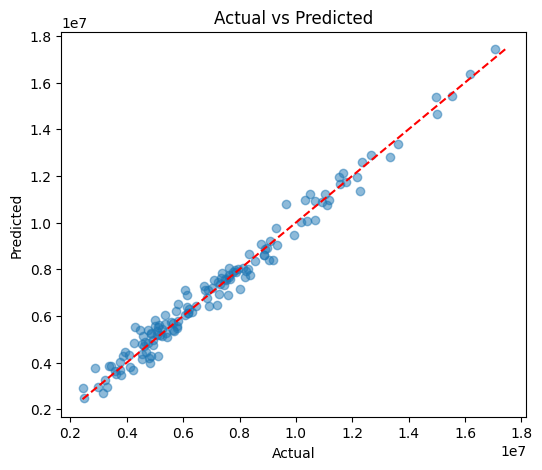

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Print `model.coef_` alongside `X.columns` — the noise features (founder_age, office_plants_count, logo_color_score) should shrink to (near) zero, while funding_raised, team_size, monthly_revenue, and growth_rate stay non-zero.
- This is Lasso doing automatic feature selection — a huge practical advantage when you have many candidate features and aren't sure which matter.
- Next steps: try `alpha` way too high and watch even genuine features get zeroed out (underfitting).

---
# Project 2 — Your Turn
**Dataset:** Car Crashes dataset (`seaborn.load_dataset('car_crashes')`) — predict `total` crashes per state from other numeric crash-related features (some may be more predictive than others).

```python
import seaborn as sns
car_crashes = sns.load_dataset('car_crashes')
```
**Tasks:** scale features, use `LassoCV` to find the best alpha, train Lasso, evaluate with MAE/RMSE/R², and check which coefficients got zeroed out.
